In [1]:
""" Carbon fluxes in Paul's observations """
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from utils.constants import *
from utils.paths import *
from utils.plotting import *
from utils.analysis import *
from scipy.stats import linregress, t

prefix_list = ['UQ_20240315']
N_list = [2000,2000]
BLOCK = 200
VAR_LIST = ["ANPPtree", "ANPPshrub", "NPPmoss", "BGNPP", "NPP", "HR", "NEE"]

In [2]:
def get_obs():
    """ Get the observational slope & value at ambient chamber """
    plot_list = [f'P{p:02g}' for p in chamber_list_complete]

    obs_data = pd.read_excel('SPRUCE C Budget Summary 28Apr2022EXP.xlsx',
                             sheet_name = 'DataForPythonRead', skiprows = 1, engine = 'openpyxl')
    obs_data = obs_data.set_index(['Plot', 'Year']).sort_index(axis = 0)
    ## obs_data = pd.concat([obs_data, pd.DataFrame(np.nan, index = pd.MultiIndex.from_product([plot_list, [2015]]), columns = obs_data.columns)], axis = 0)
    obs_data = obs_data.sort_index()
    ## Do not use 2020 value
    ##obs_data.loc[(slice(None), 2020), :] = np.nan

    obs_data['NPP'] = obs_data['ANPP Tree (~48%C)'] + obs_data['ANPP Shrub (~50%C)'] + obs_data['BNPP Tree & Shrub'] + obs_data['NPP Sphag.']
    obs_data['ANPPtree'] = obs_data['ANPP Tree (~48%C)']
    obs_data['ANPPshrub'] = obs_data['ANPP Shrub (~50%C)']
    obs_data['NPPmoss'] = obs_data['NPP Sphag.']
    obs_data['BGNPP'] = obs_data['BNPP Tree & Shrub']
    obs_data['HR'] = obs_data['RHCO2']
    obs_data['NEE'] = obs_data['NCE'] # positive = coming out of the ecosystem

    t2m_obs = obs_data.loc[:, 'Mean Annual Temp. at 2 m']
    obs_data = obs_data.loc[:, VAR_LIST]

    collection = pd.DataFrame(np.nan,
                              index = pd.MultiIndex.from_product([VAR_LIST, ['amb', 'elev']]),
                              columns = ['mean', 'mean_std', 'slope', 'slope_std'])
    collection.index.names = ['Variable', 'CO2']

    for varname in VAR_LIST:
        for co2 in ['amb','elev']:
            if co2 == 'amb':
                filt = obs_data.index.get_level_values(0).isin([plot_list[0]] + plot_list[1::2])
            else:
                filt = obs_data.index.get_level_values(0).isin(plot_list[2::2])
            obs_temp = obs_data.loc[filt, varname]
            obs_T    = t2m_obs.loc[filt]

            res = linregress(obs_T, obs_temp)

            ts = abs(t.ppf(0.05, len(obs_T) - 2))

            collection.loc[(varname, co2), 'slope'] = res.slope
            collection.loc[(varname, co2), 'slope_std'] = ts * res.stderr

            # use the average of all the chambers to be compatible with simulated results
            # obs_temp = obs_data.loc[obs_data.index.get_level_values(0) == plot_list[0], varname] # T0
            collection.loc[(varname, co2), 'mean'] = obs_temp.mean()
            collection.loc[(varname, co2), 'mean_std'] = obs_temp.std()

    return collection

In [3]:
# the dimensions are:
#   N sims x VAR_LIST x (amb, elev) x (mean, mean_std, slope, ts * slope_std)
collection_sim = {}

for N, prefix in zip(N_list, prefix_list):
    collect = np.empty([N, len(VAR_LIST), 2, 4], float)
    for b in range(0, N // BLOCK):
        collect[(b*BLOCK):((b + 1)*BLOCK), :, :] = np.load(os.path.join(path_out, "extract", prefix, f"ensemble_collection_part{b:03g}.bin"), allow_pickle=True)
    # convert Inf's to NaN
    collect = np.where(~((collect == np.inf) | (collect == -np.inf)), collect, np.nan)
    # convert unit from gC m-2 s-1 (per year) to gC m-2 (per year)
    collect = collect * 365 * 86400
    # revert the signs of NEE & HR to be compatible with Paul's data
    collect[:, 5:, :, :] = - collect[:, 5:, :, :]

    collection_sim[prefix] = collect

In [4]:
collection_sim.keys()

dict_keys(['UQ_20240315'])

In [5]:
# Get the parameters
def get_params(prefix, parname, N, ensemble_members = range(1, 2001)):
#    prefix = 'UQ_20240311'
#    parname = 'kmin_nuptake'
#    N = 2000
    uqroot = os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', 'UQ', 
                            f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC')
    N = len(ensemble_members)
    count = 0
    for b in ensemble_members:
        hr = xr.open_dataset( os.path.join(uqroot, f'g{b:05d}', f'clm_params_{b:05d}.nc') )
        parvals = hr[parname].values
        hr.close()
        if count == 0:
            if parvals.shape == ():
                parcollect = np.full([N, 1], np.nan)
            else:
                parcollect = np.full([N, len(parvals)], np.nan)
        if parvals.shape == ():
            parcollect[count, 0] = parvals
        else:
            parcollect[count, :] = parvals.reshape(-1)
        count = count + 1
    return parcollect

In [7]:
collection_obs = get_obs()
collection_obs

mean    mean_std      slope  slope_std
Variable  CO2                                               
ANPPtree  amb    91.700000   44.126273  -0.816665   3.341434
          elev   88.830000   27.911154  -0.338848   2.684829
ANPPshrub amb   103.116112   34.610871   5.314703   2.127957
          elev  133.490456   44.819100   8.823627   3.251274
NPPmoss   amb    91.771972   56.616537 -11.185588   2.819775
          elev   62.514800   43.962431  -7.533369   3.470893
BGNPP     amb    75.238542   36.469272   6.878300   1.919949
          elev   79.405625   43.111744  10.339268   2.485481
NPP       amb   361.826626   65.875321   0.190750   5.000575
          elev  364.240881   64.278793  11.290678   5.011837
HR        amb  -434.134483   98.867655 -21.632399   4.120561
          elev -464.748872   88.519071 -23.094001   4.183391
NEE       amb  -195.634120  205.887674 -36.874473  11.399360
          elev -235.051711  153.947618 -32.077410  10.644657

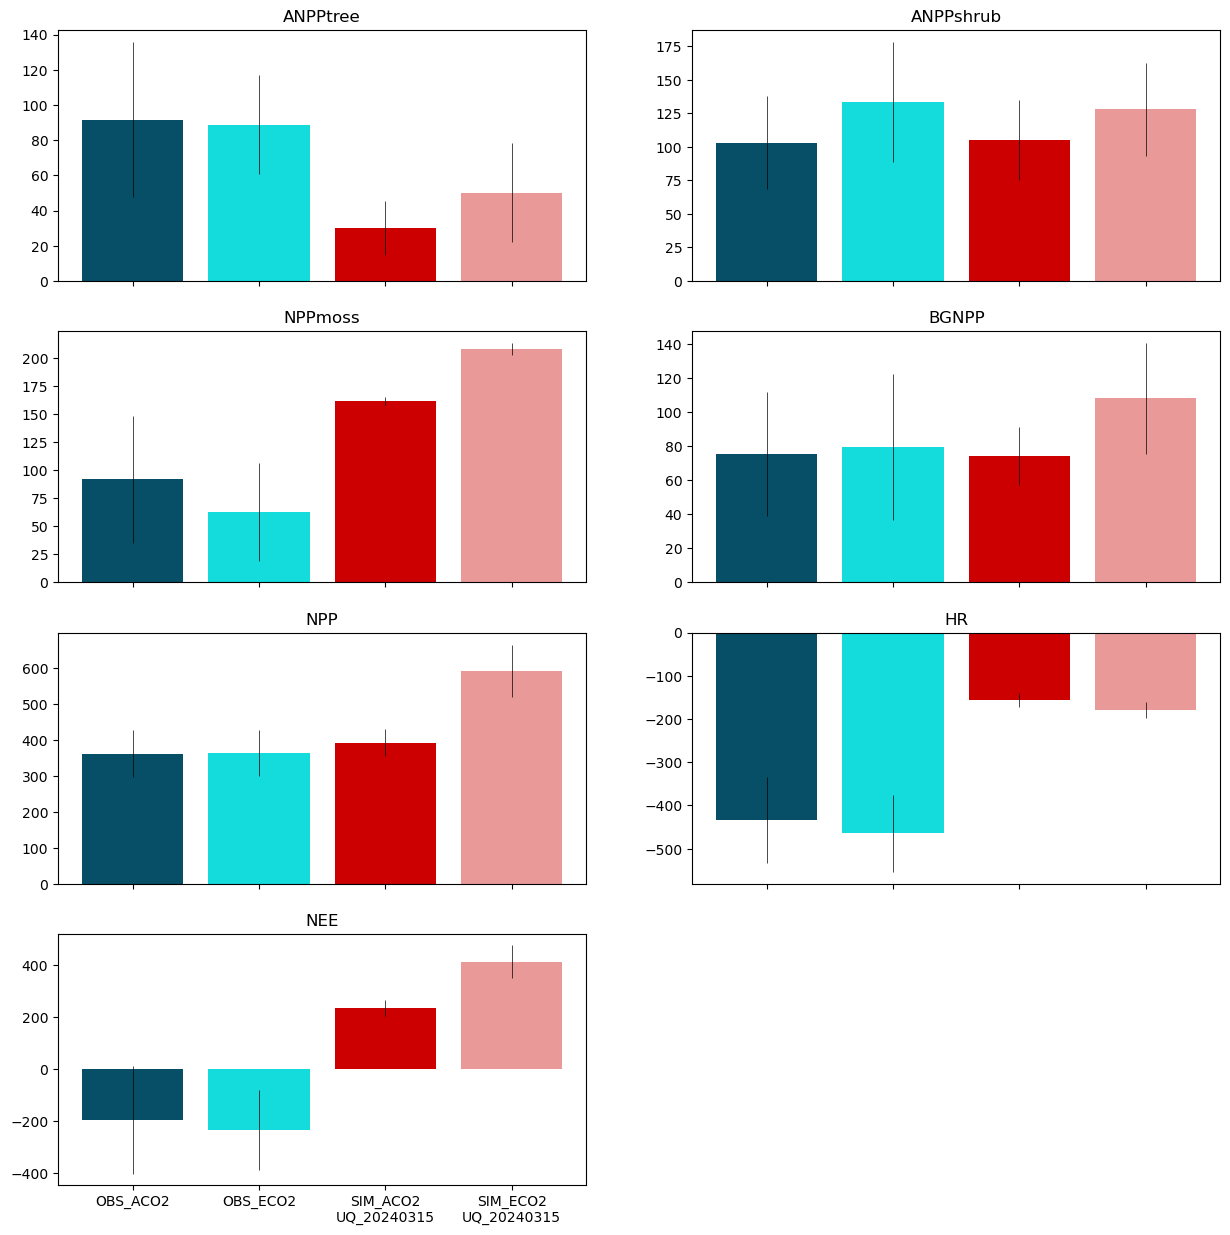

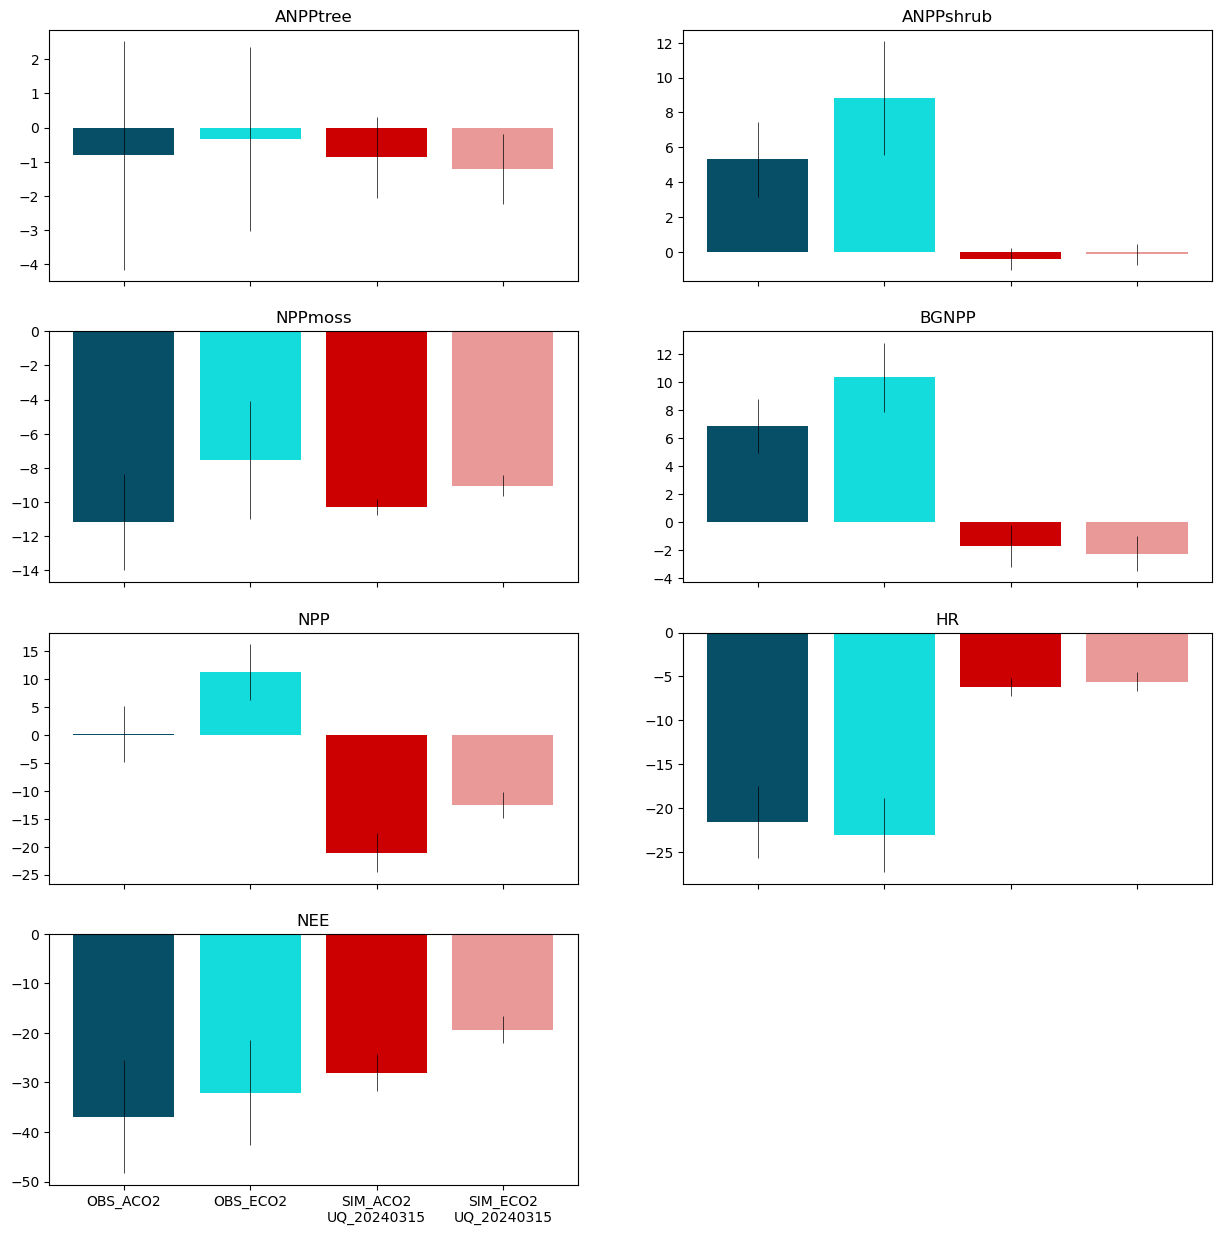

In [8]:
for quantity in ['mean', 'slope']:
    fig, axes = plt.subplots(4, 2, figsize = (15, 15), sharex = True, sharey = False)
    for i, ax in enumerate(axes.flat):
        if i >= len(VAR_LIST):
            ax.axis('off')
        else:
            varname = VAR_LIST[i]
            ax.bar([1, 2], collection_obs.loc[varname, quantity].values, 
                   color = ['#074e67', '#14dcdc'])
            ax.errorbar([1, 2], collection_obs.loc[varname, quantity].values, 
                        collection_obs.loc[varname, f'{quantity}_std'].values, 
                        ecolor = 'k', lw = 0, elinewidth = 0.5)
            ax.set_title(varname)

            if quantity == 'mean':
                k = 0
            else:
                k = 2

            for j, prefix in enumerate(prefix_list):
                temp = np.nanmean(collection_sim[prefix][:, i, :, k], axis = 0)
                temp_std = np.nanstd(collection_sim[prefix][:, i, :, k], axis = 0)

                ax.bar([3+j*2, 4+j*2], temp, color = ['#cc0000', '#ea9999'])
                ax.errorbar([3+j*2, 4+j*2], temp, temp_std, ecolor = 'k', lw = 0, elinewidth = 0.5)

        if i >= 5:
            ax.set_xticks(range(1, 3 + 2 * len(prefix_list)))
            ax.set_xticklabels(['OBS_ACO2', 'OBS_ECO2'] + [f'{a}\n{prefix}' for prefix in prefix_list for a in  ['SIM_ACO2', 'SIM_ECO2']])

In [8]:
collection_sim['UQ_20240315'].shape

(2000, 7, 2, 4)

## Do more single run checks on parameter relationships

In [29]:
prefix = 'UQ_20240315'
N = 2000

# Tree to shrub ratios
tree_shrub_ratio = collection_sim[prefix][:, 0, :, 0].mean(axis = 1) / collection_sim[prefix][:, 1, :, 0].mean(axis = 1)

# BGNPP/AGNPP
bg_ag_ratio = collection_sim[prefix][:, 2, :, 0].mean(axis = 1) / \
    collection_sim[prefix][:, 0:2, :, 0].sum(axis = 1).mean(axis = 1)

# The sensitivity of tree AGNPP to temperature
tree_sensitivity = collection_sim[prefix][:, 0, :, 2].mean(axis = 1)
shrub_sensitivity = collection_sim[prefix][:, 1, :, 2].mean(axis = 1)
bgnpp_sensitivity = collection_sim[prefix][:, 2, :, 2].mean(axis = 1)

# HR & NEE level
hr = collection_sim[prefix][:, 5, :, 0].mean(axis = 1)
hr_sensitivity = collection_sim[prefix][:, 5, :, 2].mean(axis = 1)
nee = collection_sim[prefix][:, 6, :, 0].mean(axis = 1)
nee_sensitivity = collection_sim[prefix][:, 6, :, 2].mean(axis = 1)

Text(0, 0.5, 'Sensitivity of NEE to warming')

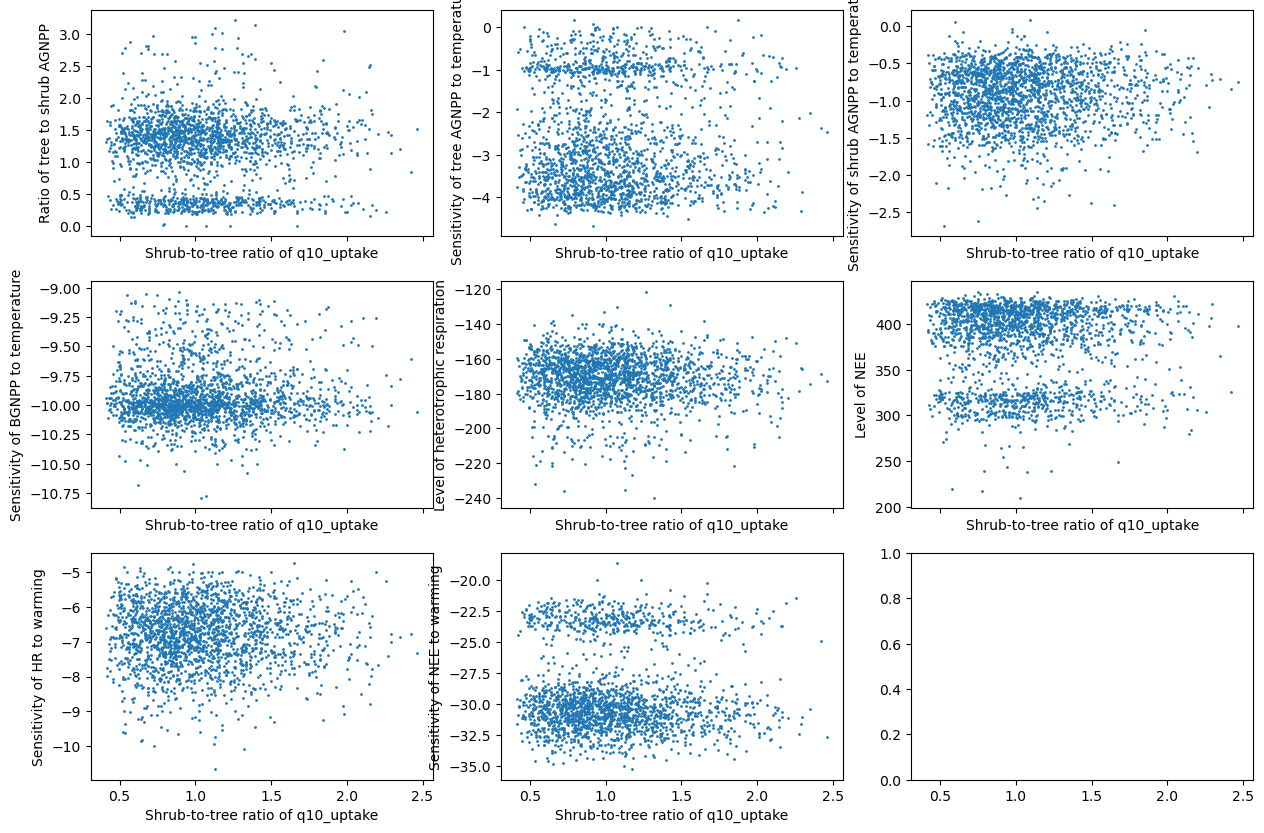

In [22]:
# without PFT-specific sizing, there is no result what so ever
q10_collect = get_params(prefix, 'q10_uptake', 2000)
q10_ratio = q10_collect[:,11] / q10_collect[:,2:3].mean(axis = 1)

fig, axes = plt.subplots(3, 3, figsize = (15, 10), sharex = True)

ax = axes.flat[0]
ax.plot(q10_ratio, tree_shrub_ratio, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Ratio of tree to shrub AGNPP')

ax = axes.flat[1]
ax.plot(q10_ratio, tree_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of tree AGNPP to temperature')

ax = axes.flat[2]
ax.plot(q10_ratio, shrub_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of shrub AGNPP to temperature')

ax = axes.flat[3]
ax.plot(q10_ratio, bgnpp_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of BGNPP to temperature')

ax = axes.flat[4]
ax.plot(q10_ratio, hr, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Level of heterotrophic respiration')

ax = axes.flat[5]
ax.plot(q10_ratio, nee, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Level of NEE')

ax = axes.flat[6]
ax.plot(q10_ratio, hr_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of HR to warming')

ax = axes.flat[7]
ax.plot(q10_ratio, nee_sensitivity, 'o', ms = 1)
ax.set_xlabel('Shrub-to-tree ratio of q10_uptake')
ax.set_ylabel('Sensitivity of NEE to warming')

In [ ]:
# kmin_nuptake has the desired impact, but not large enough
# note smaller kmin_nuptake means greater uptake capability

kmincollect = get_params(prefix, 'kmin_nuptake', 2000)

xtemp = (kmincollect[:, 2] + kmincollect[:, 3]) / 2 / kmincollect[:, 11]

fig, axes = plt.subplots(2, 2, figsize = (10, 10))

ax = axes.flat[0]
ax.plot(xtemp, tree_shrub_ratio, 'o', ms = 1)
ax.set_xlabel('Ratio of kmin_nuptake of tree to shrub')
ax.set_ylabel('Ratio of tree to shrub AGNPP')

ax = axes.flat[1]
ax.plot(xtemp, tree_sensitivity, 'o', ms = 1)
ax.set_xlabel('Ratio of kmin_nuptake of tree to shrub')
ax.set_ylabel('Sensitivity of tree AGNPP to temperature')

ax = axes.flat[2]
ax.plot(xtemp, shrub_sensitivity, 'o', ms = 1)
ax.set_xlabel('Ratio of kmin_nuptake of tree to shrub')
ax.set_ylabel('Sensitivity of shrub AGNPP to temperature')

ax = axes.flat[3]
ax.plot(xtemp, bgnpp_sensitivity, 'o', ms = 1)
ax.set_xlabel('Ratio of kmin_nuptake of tree to shrub')
ax.set_ylabel('Sensitivity of BGNPP to temperature')

In [ ]:
# compet_pft_sminn
competn_collect = get_params(prefix, 'compet_pft_sminn', 2000)

# xtemp = (competn_collect[:, 2] + competn_collect[:, 3]) / 2 / competn_collect[:, 11]
xtemp = competn_collect[:, 11]

fig, axes = plt.subplots(2, 2, figsize = (10, 10))

ax = axes.flat[0]
ax.plot(xtemp, tree_shrub_ratio, 'o', ms = 1)
ax.set_xlabel('Ratio of competn_collect of tree to shrub')
ax.set_xscale('log')
ax.set_ylabel('Ratio of tree to shrub AGNPP')

ax = axes.flat[1]
ax.plot(xtemp, tree_sensitivity, 'o', ms = 1)
ax.set_xlabel('Ratio of competn_collect of tree to shrub')
ax.set_xscale('log')
ax.set_ylabel('Sensitivity of tree AGNPP to temperature')

ax = axes.flat[2]
ax.plot(xtemp, shrub_sensitivity, 'o', ms = 1)
ax.set_xlabel('Ratio of competn_collect of tree to shrub')
ax.set_xscale('log')
ax.set_ylabel('Sensitivity of shrub AGNPP to temperature')

ax = axes.flat[3]
ax.plot(xtemp, bgnpp_sensitivity, 'o', ms = 1)
ax.set_xlabel('Ratio of competn_collect of tree to shrub')
ax.set_xscale('log')
ax.set_ylabel('Sensitivity of BGNPP to temperature')

In [ ]:
# froot_leaf larger for trees means lower tree AGNPP compared to shrub
# especially for the evergreen. whereas froot_leaf larger for shrub has
# the opposite effect. Larger belowground allocation means lower 
# aboveground advantage, makes sense

# Evergreen is dominating the BG-to-AG ratio in the eventual result

alloccollect = get_params(prefix, 'froot_leaf', 2000)

fig, axes = plt.subplots(2, 2, figsize = (10, 10))
for i, pft in enumerate([2, 3, 11]):
    ax = axes.flat[i]
    ax.plot(alloccollect[:, pft], tree_shrub_ratio, 'o', ms = 1)
    ax.set_xlabel('Root to leaf allocation ratio')
    ax.set_ylabel('Ratio of tree AGNPP to shrub AGNPP')

    # observed level
    obs = collection_obs.loc['ANPPtree', 'mean'].mean() / \
        collection_obs.loc['ANPPshrub', 'mean'].mean()
    ax.axhline(obs, color = 'r', lw = 2)

# when shrub's ratio < 0.25, what does the tree AGNPP & shrub AGNPP compare to obs?


fig, axes = plt.subplots(2, 2, figsize = (10, 10))
for i, pft in enumerate([2, 3, 11]):
    ax = axes.flat[i]
    ax.plot(alloccollect[:, pft], bg_ag_ratio, 'o', ms = 1)
    ax.set_xlabel('Root to leaf allocation ratio')
    ax.set_ylabel('Ratio of BGNPP to AGNPP')

    # observed level
    obs = collection_obs.loc['BGNPP', 'mean'].mean() / \
        (collection_obs.loc['ANPPtree', 'mean'].mean() + \
        collection_obs.loc['ANPPshrub', 'mean'].mean()) 
    ax.axhline(obs, color = 'r', lw = 2)

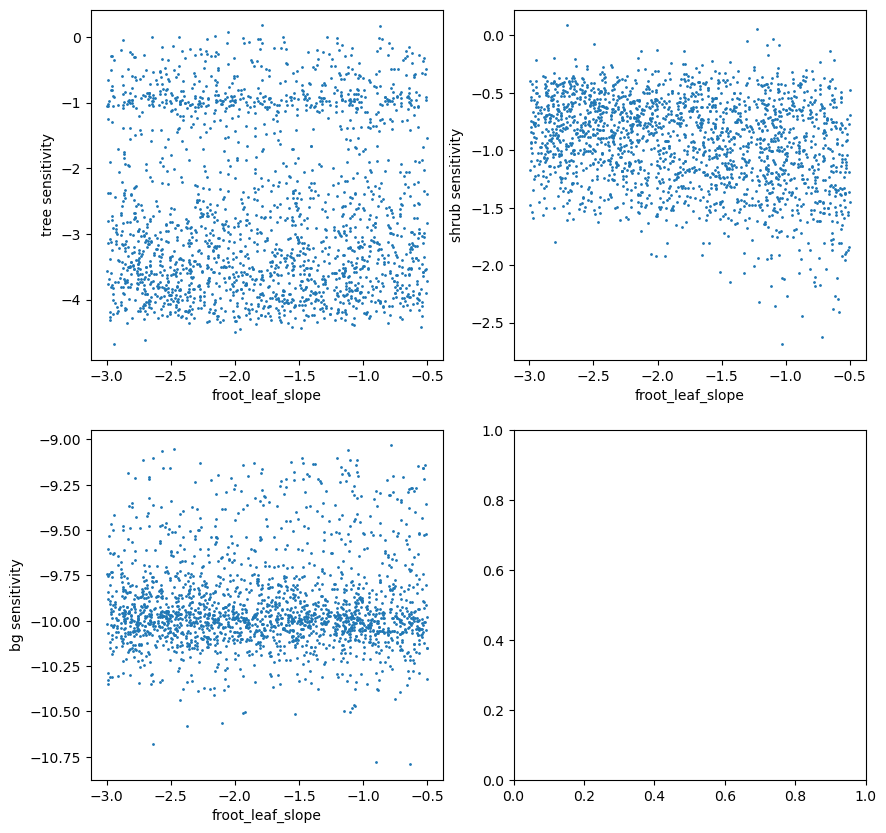

In [12]:
#alloccollect = get_params(prefix, 'froot_leaf_slope', 2000)

fig, axes = plt.subplots(2, 2, figsize = (10, 10))
for i, (name,sens) in enumerate(zip(["tree","shrub","bg"],
                                    [tree_sensitivity, shrub_sensitivity,bgnpp_sensitivity])):
    ax = axes.flat[i]
    ax.plot(alloccollect[:, 11], sens, 'o', ms = 1)
    ax.set_xlabel('froot_leaf_slope')
    ax.set_ylabel(f'{name} sensitivity')

In [ ]:
""" Check the sensitivity of all quantities to alpha_fpg & alpha_fpg_p
    if insensitive, set to constants = 3
"""
alpha_fpg = get_params(prefix, 'alpha_fpg', 2000)
alpha_fpg_p = get_params(prefix, 'alpha_fpg_p', 2000)

fig, axes = plt.subplots(4, 4, figsize = (16, 16))
for i, col in enumerate(collection_obs.index.levels[0]):
    for j, stat in enumerate(['mean', 'slope']):
        ax = axes.flat[j*8 + i]

        obs = collection_obs.loc[col, stat].mean()
        sim = collection_sim[prefix][:, i, :, j * 2].mean(axis = 1)

        ax.axhline(obs, color = 'r', lw = 2)
        ax.plot(alpha_fpg, sim, 'o', ms = 1, color = 'b')
        ax.plot(alpha_fpg_p, sim, 'o', ms = 1, color = 'magenta')

## Find the parameter ranges for desired sensitivities and mean

In [48]:
selected_runs = np.where(
    (shrub_sensitivity >= -0.2) & (tree_sensitivity < 0.0) & (bgnpp_sensitivity > -10)
)[0] + 1
print(selected_runs)

[ 472  520  653  994 1261 1300 1326 1481 1505 1529]


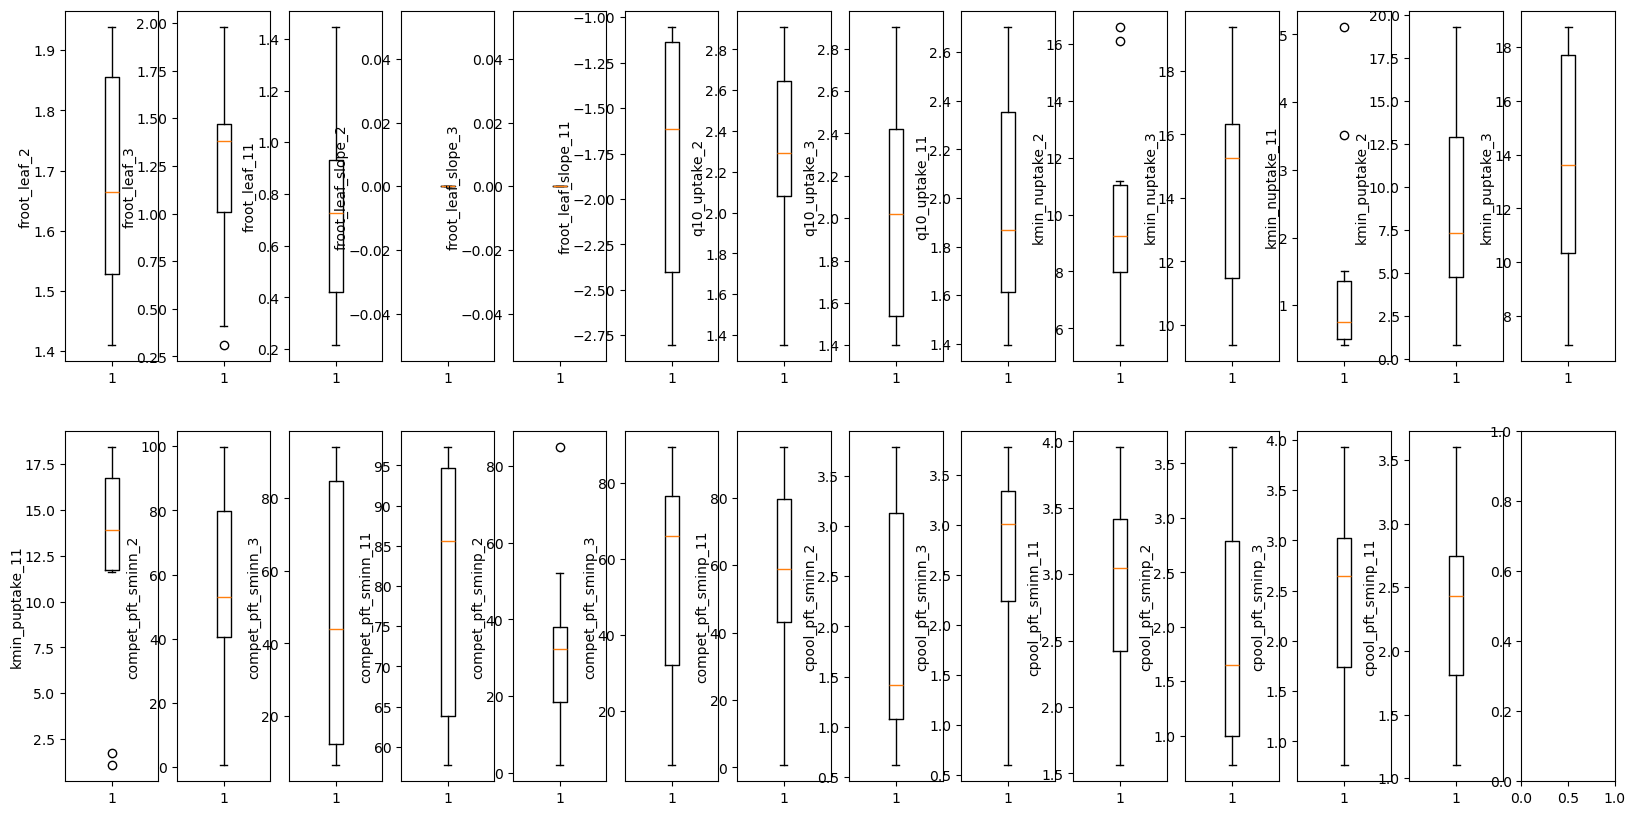

In [54]:
params_collect = {}
for parname in ['froot_leaf', 'froot_leaf_slope', 'q10_uptake', 'kmin_nuptake', 'kmin_puptake', 
                'compet_pft_sminn', 'compet_pft_sminp', 'compet_pft_sminp', 
                'cpool_pft_sminn', 'cpool_pft_sminp']: # , 'alpha_fpg', 'alpha_fpg_p'
    parvals = get_params(prefix, parname, 2000, selected_runs)
    if parvals.shape[1] == 1:
        params_collect[parname] = parvals
    else:
        for pft in [2, 3, 11]:
            params_collect[f'{parname}_{pft}'] = parvals[:, pft]

params_list = list(params_collect.keys())
fig, axes = plt.subplots(2, int(np.ceil(len(params_collect) / 2)), figsize = (20, 10))
fig.subplots_adjust(wspace = 0.2)
for i in range(len(params_list)):
    ax = axes.flat[i]
    ax.boxplot(params_collect[params_list[i]])
    ax.set_ylabel(params_list[i], labelpad=0)